In [1]:
import torch
from transformers import AutoModelForCausalLM

from janus.models import MultiModalityCausalLM, VLChatProcessor
import numpy as np
import os, time
import PIL.Image

# for probe
from probes.attn_probe_runtime import attach_layer_indices, enable_attention_probe, set_probe_callback, TokenStat
# from probes.layer_hooks import register_lasttoken_hooks
import torch
import torch.nn.functional as F
from datetime import datetime

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

# specify the path to the model
# model_path = "deepseek-ai/Janus-1.3B"
model_path = "/home/vlgd/Models/Janus-Pro-1B/"
# vl_chat_processor: VLChatProcessor = VLChatProcessor.from_pretrained(model_path)
# tokenizer = vl_chat_processor.tokenizer

vl_gpt: MultiModalityCausalLM = AutoModelForCausalLM.from_pretrained(
    model_path, trust_remote_code=True
)

/home/vlgd/anaconda3/envs/gsdpy310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python version is above 3.10, patching the collections module.


/home/vlgd/anaconda3/envs/gsdpy310/lib/python3.10/site-packages/transformers/models/auto/image_processing_auto.py:590: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(


In [2]:
embeddings = vl_gpt.gen_vision_model.quantize.embedding.weight.detach().cpu()
print(embeddings.shape)
print(embeddings.mean(axis=0), embeddings.std(axis=0))

torch.Size([16384, 8])
tensor([-0.0177,  0.0298, -0.0025,  0.0141, -0.0090,  0.0054,  0.0150,  0.0394]) tensor([0.3587, 0.3665, 0.3571, 0.3541, 0.3668, 0.3587, 0.3833, 0.3804])


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

E = embeddings.detach().cpu().numpy()
N, D = E.shape
print(E.shape)

(16384, 8)


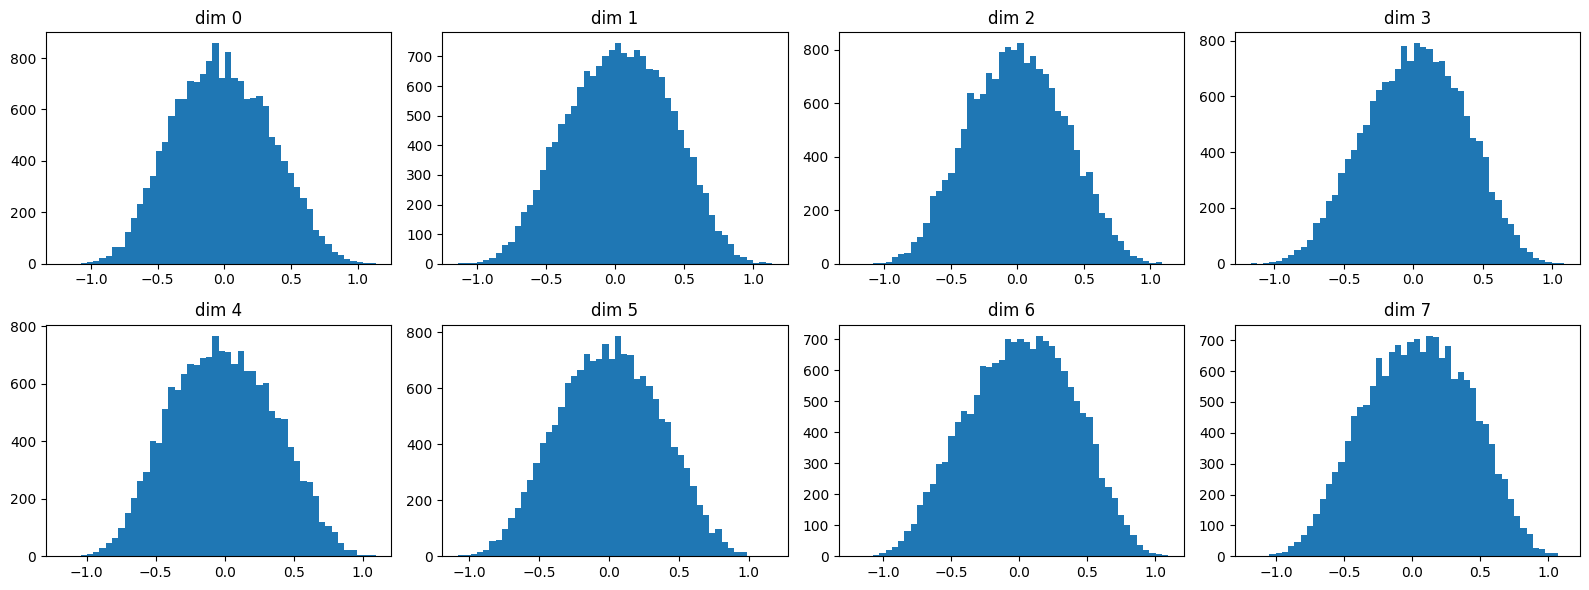

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i in range(D):
    axes[i].hist(E[:, i], bins=50)
    axes[i].set_title(f"dim {i}")
plt.tight_layout()
plt.show()

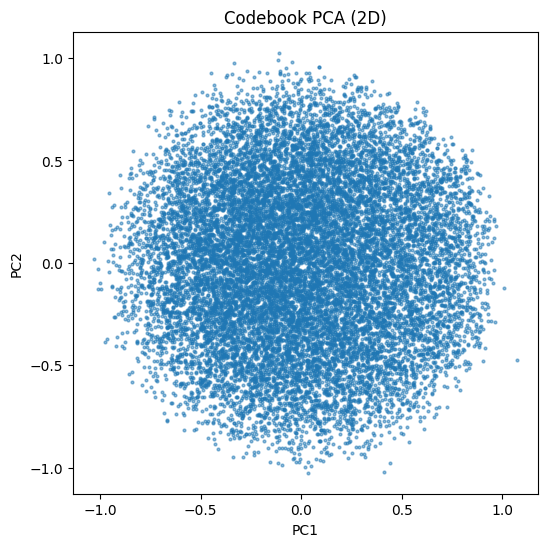

In [8]:
pca = PCA(n_components=2)
E_pca = pca.fit_transform(E)  # [16384, 2]

plt.figure(figsize=(6, 6))
plt.scatter(E_pca[:, 0], E_pca[:, 1], s=4, alpha=0.5)
plt.title("Codebook PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 16384 samples in 0.022s...
[t-SNE] Computed neighbors for 16384 samples in 3.842s...
[t-SNE] Computed conditional probabilities for sample 1000 / 16384
[t-SNE] Computed conditional probabilities for sample 2000 / 16384
[t-SNE] Computed conditional probabilities for sample 3000 / 16384
[t-SNE] Computed conditional probabilities for sample 4000 / 16384
[t-SNE] Computed conditional probabilities for sample 5000 / 16384
[t-SNE] Computed conditional probabilities for sample 6000 / 16384
[t-SNE] Computed conditional probabilities for sample 7000 / 16384
[t-SNE] Computed conditional probabilities for sample 8000 / 16384
[t-SNE] Computed conditional probabilities for sample 9000 / 16384
[t-SNE] Computed conditional probabilities for sample 10000 / 16384
[t-SNE] Computed conditional probabilities for sample 11000 / 16384
[t-SNE] Computed conditional probabilities for sample 12000 / 16384
[t-SNE] Computed conditional probabilities for sam

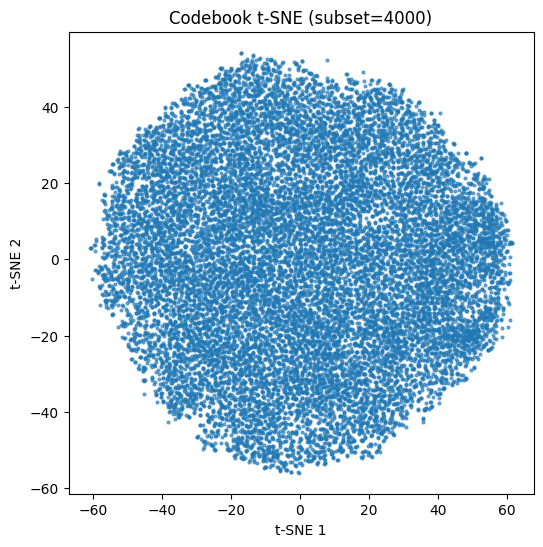

In [ ]:
subset = 4000  # 可以调小/调大
idx = np.random.choice(N, size=subset, replace=False)
E_sub = E

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    verbose=1,
)
E_tsne = tsne.fit_transform(E_sub)  # [subset, 2]

plt.figure(figsize=(6, 6))
plt.scatter(E_tsne[:, 0], E_tsne[:, 1], s=4, alpha=0.6)
plt.title(f"Codebook t-SNE (subset={subset})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import os

probe_dir = "probe_runtime/"

bs_prob = np.load(os.path.join(probe_dir, "baseline_prob.npy"))
pl_prob = np.load(os.path.join(probe_dir, "row_parallel_prob.npy"))
bs_token = np.load(os.path.join(probe_dir, "baseline_token.npy"))
pl_token = np.load(os.path.join(probe_dir, "row_parallel_token.npy"))

H, W = 24, 24 
eps = 1e-12
B, N, V = bs_prob.shape


In [14]:
bs_flat = bs_token.reshape(-1)
pl_flat = pl_token.reshape(-1)
same_mask = (bs_flat == pl_flat)
diff_mask = ~same_mask

print("total positions:", bs_flat.shape[0])
print("same:", same_mask.sum(), "diff:", diff_mask.sum())

total positions: 2880
same: 3 diff: 2877


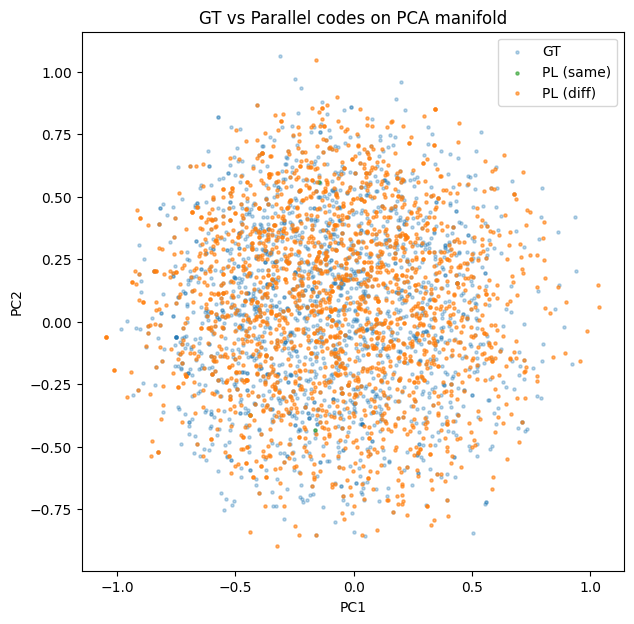

In [16]:
num_sample = 4000
idx_all = np.arange(bs_flat.shape[0])

idx_same = idx_all[same_mask]
idx_diff = idx_all[diff_mask]

sample_same = np.random.choice(idx_same, size=min(num_sample//2, idx_same.shape[0]), replace=False) if idx_same.size > 0 else np.array([], dtype=int)
sample_diff = np.random.choice(idx_diff, size=min(num_sample//2, idx_diff.shape[0]), replace=False) if idx_diff.size > 0 else np.array([], dtype=int)

sample_idx = np.concatenate([sample_same, sample_diff])

gt_s = bs_flat[sample_idx]
pl_s = pl_flat[sample_idx]
same_s = gt_s == pl_s

gt_pca = E_sub[gt_s]
pl_pca = E_sub[pl_s]

plt.figure(figsize=(7, 7))
plt.scatter(gt_pca[:, 0], gt_pca[:, 1], s=5, alpha=0.3, label="GT", color="C0")

plt.scatter(pl_pca[ same_s, 0], pl_pca[ same_s, 1], s=5, alpha=0.6, label="PL (same)", color="C2")
plt.scatter(pl_pca[~same_s, 0], pl_pca[~same_s, 1], s=5, alpha=0.6, label="PL (diff)", color="C1")

plt.legend()
plt.title("GT vs Parallel codes on PCA manifold")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

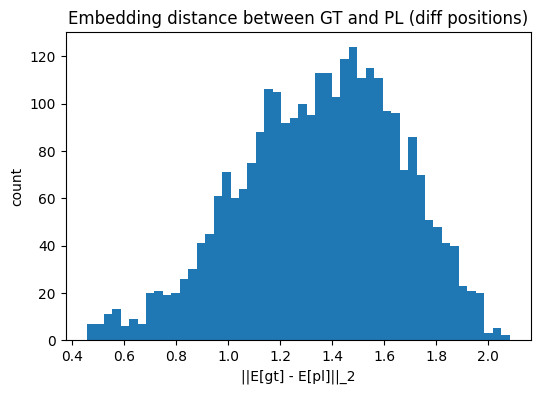

dist mean: 1.3538637 std: 0.30809745 min: 0.45607194 max: 2.081705


In [17]:
gt_diff = bs_flat[diff_mask]
pl_diff = pl_flat[diff_mask]

E_gt = E[gt_diff]
E_pl = E[pl_diff]

dist = np.linalg.norm(E_gt - E_pl, axis=-1)  # L2 距离

plt.figure(figsize=(6, 4))
plt.hist(dist, bins=50)
plt.title("Embedding distance between GT and PL (diff positions)")
plt.xlabel("||E[gt] - E[pl]||_2")
plt.ylabel("count")
plt.show()

print("dist mean:", dist.mean(), "std:", dist.std(), "min:", dist.min(), "max:", dist.max())

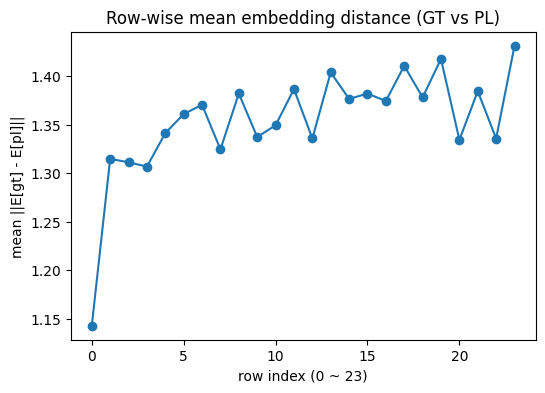

In [ ]:
H = 24
W = 24
B, N = bs_token.shape

gt_2d = bs_token.reshape(B, H, W)
pl_2d = pl_token.reshape(B, H, W)

row_dist = []

for r in range(H):
    gt_r = gt_2d[:, r].reshape(-1)
    pl_r = pl_2d[:, r].reshape(-1)
    diff_r = gt_r != pl_r
    if diff_r.any():
        E_gt_r = E[gt_r[diff_r]]
        E_pl_r = E[pl_r[diff_r]]
        d_r = np.linalg.norm(E_gt_r - E_pl_r, axis=-1).mean()
    else:
        d_r = 0.0
    row_dist.append(d_r)

plt.figure(figsize=(6, 4))
plt.plot(row_dist, marker="o")
plt.title("Row-wise mean embedding distance (GT vs PL)")
plt.xlabel("row index (0 ~ 23)")
plt.ylabel("mean ||E[gt] - E[pl]||")
plt.show()

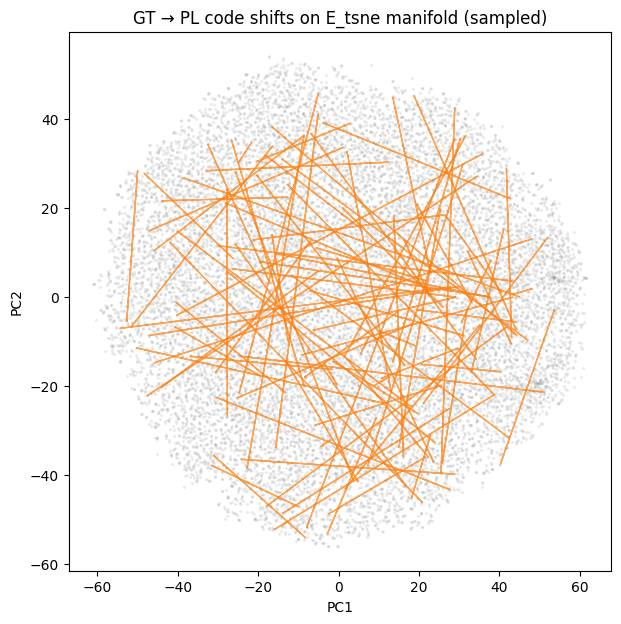

In [28]:
num_arrows = 100
idx_diff_small = np.random.choice(idx_diff, size=min(num_arrows, idx_diff.shape[0]), replace=False)

gt_a = bs_flat[idx_diff_small]
pl_a = pl_flat[idx_diff_small]

gt_p = E_tsne[gt_a]
pl_p = E_tsne[pl_a]

plt.figure(figsize=(7, 7))
plt.scatter(E_tsne[:, 0], E_tsne[:, 1], s=2, alpha=0.1, color="gray")

for i in range(gt_p.shape[0]):
    x0, y0 = gt_p[i]
    x1, y1 = pl_p[i]
    plt.arrow(x0, y0, x1 - x0, y1 - y0, head_width=0.05, alpha=0.7, color="C1", length_includes_head=True)

plt.title("GT → PL code shifts on E_tsne manifold (sampled)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


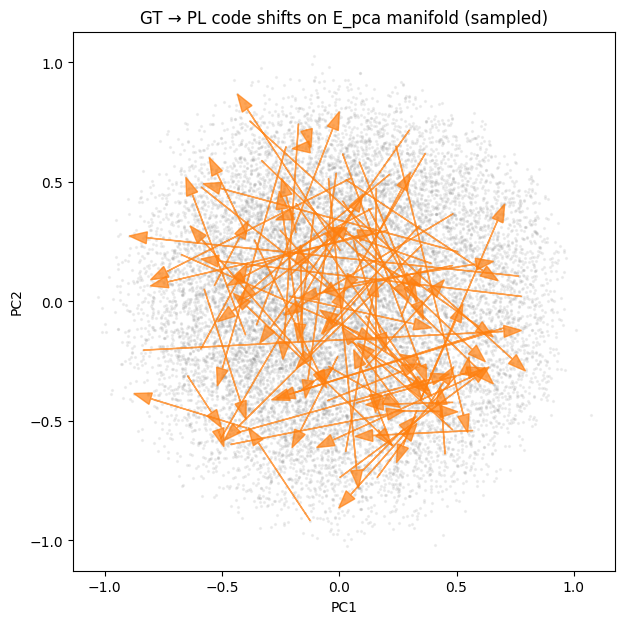

In [29]:
num_arrows = 100
idx_diff_small = np.random.choice(idx_diff, size=min(num_arrows, idx_diff.shape[0]), replace=False)

gt_a = bs_flat[idx_diff_small]
pl_a = pl_flat[idx_diff_small]

gt_p = E_pca[gt_a]
pl_p = E_pca[pl_a]

plt.figure(figsize=(7, 7))
plt.scatter(E_pca[:, 0], E_pca[:, 1], s=2, alpha=0.1, color="gray")

for i in range(gt_p.shape[0]):
    x0, y0 = gt_p[i]
    x1, y1 = pl_p[i]
    plt.arrow(x0, y0, x1 - x0, y1 - y0, head_width=0.05, alpha=0.7, color="C1", length_includes_head=True)

plt.title("GT → PL code shifts on E_pca manifold (sampled)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [ ]:
idx_all = np.arange(bs_flat.shape[0])
idx_diff = idx_all[diff_mask]
num_arrows = 200
idx_diff_small = np.random.choice(
    idx_diff, size=min(num_arrows, idx_diff.shape[0]), replace=False
)

gt_a = bs_flat[idx_diff_small]
pl_a = pl_flat[idx_diff_small]


(2880,)


In [31]:
pca_3d = PCA(n_components=3)
E_pca_3d = pca_3d.fit_transform(E) 

tsne_3d = TSNE(
    n_components=3,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    verbose=1,
)
E_tsne_3d = tsne_3d.fit_transform(E) 

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 16384 samples in 0.025s...
[t-SNE] Computed neighbors for 16384 samples in 4.383s...
[t-SNE] Computed conditional probabilities for sample 1000 / 16384
[t-SNE] Computed conditional probabilities for sample 2000 / 16384
[t-SNE] Computed conditional probabilities for sample 3000 / 16384
[t-SNE] Computed conditional probabilities for sample 4000 / 16384
[t-SNE] Computed conditional probabilities for sample 5000 / 16384
[t-SNE] Computed conditional probabilities for sample 6000 / 16384
[t-SNE] Computed conditional probabilities for sample 7000 / 16384
[t-SNE] Computed conditional probabilities for sample 8000 / 16384
[t-SNE] Computed conditional probabilities for sample 9000 / 16384
[t-SNE] Computed conditional probabilities for sample 10000 / 16384
[t-SNE] Computed conditional probabilities for sample 11000 / 16384
[t-SNE] Computed conditional probabilities for sample 12000 / 16384
[t-SNE] Computed conditional probabilities for sam

In [ ]:
E_pca_3d[gt_a]

(200, 3)

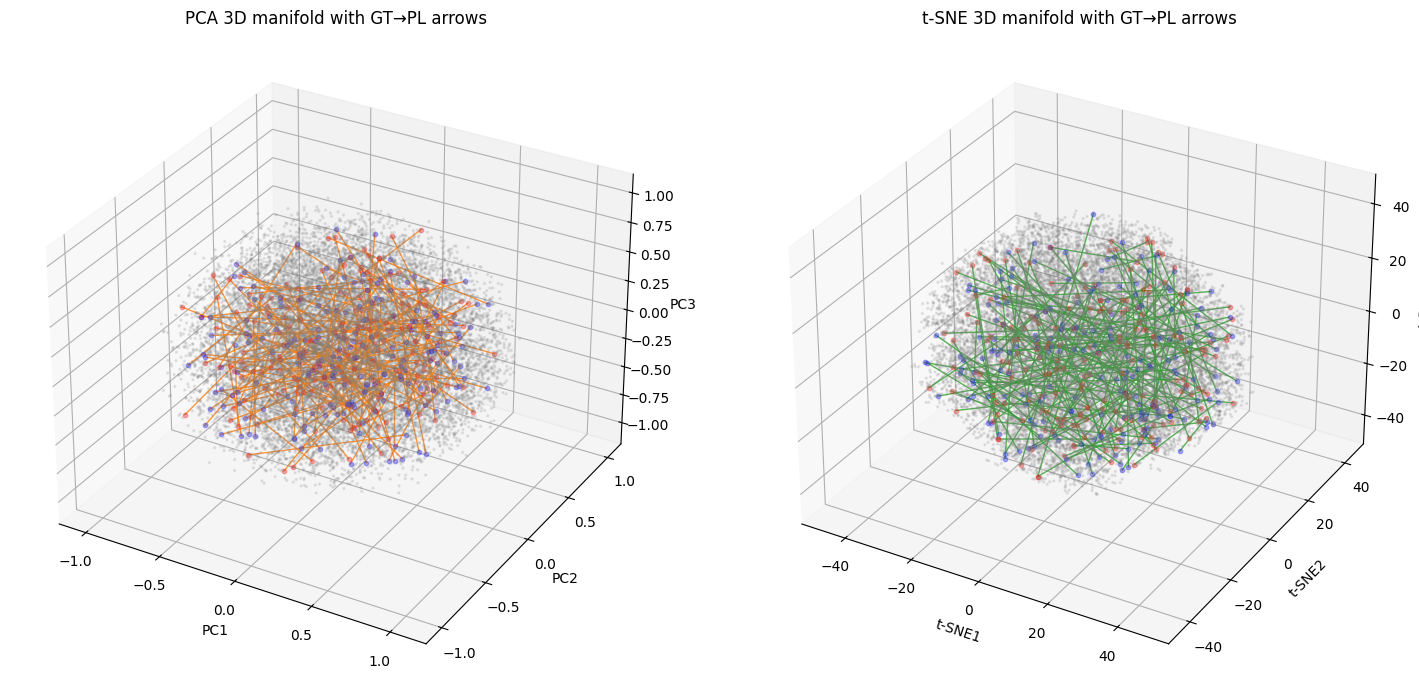

: 

In [ ]:
# fig = plt.figure(figsize=(15, 7))
fig = plt.figure(figsize=(15, 7))

ax = fig.add_subplot(121, projection='3d')
ax.scatter(E_pca_3d[:, 0], E_pca_3d[:, 1], E_pca_3d[:, 2],
           s=2, alpha=0.15, color="gray")


for x0, y0, z0, x1, y1, z1 in zip(
    E_pca_3d[gt_a][:, 0], E_pca_3d[gt_a][:, 1], E_pca_3d[gt_a][:, 2],
    E_pca_3d[pl_a][:, 0], E_pca_3d[pl_a][:, 1], E_pca_3d[pl_a][:, 2],
):
    ax.plot([x0, x1], [y0, y1], [z0, z1], color="C1", alpha=0.8, linewidth=1.0)
    ax.scatter([x0], [y0], [z0], s=10, color="red", alpha=0.3)
    ax.scatter([x1], [y1], [z1], s=10, color="blue", alpha=0.3)

ax.set_title("PCA 3D manifold with GT→PL arrows")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")


# t-SNE 3D
# fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(122, projection='3d')
ax.scatter(E_tsne_3d[:, 0], E_tsne_3d[:, 1], E_tsne_3d[:, 2],
           s=2, alpha=0.15, color="gray")

for x0, y0, z0, x1, y1, z1 in zip(
    E_tsne_3d[gt_a][:, 0], E_tsne_3d[gt_a][:, 1], E_tsne_3d[gt_a][:, 2],
    E_tsne_3d[pl_a][:, 0], E_tsne_3d[pl_a][:, 1], E_tsne_3d[pl_a][:, 2],
):
    ax.plot([x0, x1], [y0, y1], [z0, z1], color="C2", alpha=0.8, linewidth=1.0)
    ax.scatter([x0], [y0], [z0], s=10, color="red", alpha=0.3)
    ax.scatter([x1], [y1], [z1], s=10, color="blue", alpha=0.3)

ax.set_title("t-SNE 3D manifold with GT→PL arrows")
ax.set_xlabel("t-SNE1")
ax.set_ylabel("t-SNE2")
ax.set_zlabel("t-SNE3")

plt.tight_layout()
plt.show()